In [1]:
# 在开始学习代码之前，我们先必须要有一个数据（看下一个格子）
import numpy as np
import mne
import matplotlib.pyplot as plt
# 让图片显示在单元格内，而不是弹窗
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 这个数据包含一位被试的 MEG（脑磁图） 和 EEG（脑电图） 记录，是 MNE 官方教程和文档中广泛使用的标准数据集
sample_data_folder = mne.datasets.sample.data_path(path='D:\mne_data')
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
# 这里会默认输出一些信息，先不用管它们，后续再介绍
raw = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file D:\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


Opening raw data file ../data/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


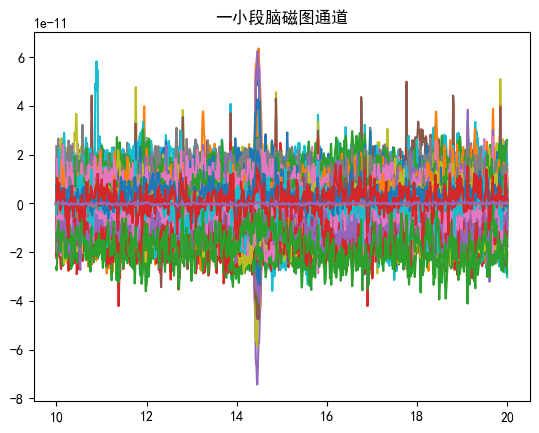

In [3]:
# import matplotlib
# 图片弹窗显示
# matplotlib.use('Qt5Agg')

# 将数据复制到了项目里
data_path = "../data/sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(data_path)

# 从 Raw 对象的 info 中挑选通道：只保留 MEG（脑磁图）通道，排除 EEG（脑电图）通道，返回的是索引编号
picks = mne.pick_types(raw.info, meg=True, eeg=False)
# 将物理时间（单位：秒）转换为对应的采样点索引，获取第 10 秒和第 20 秒对应的样本位置
t_idx = raw.time_as_index([10., 20.])
# 选取上面挑选的 MEG 通道，在 10 秒到 20 秒这个时间片段内的所有采样点
data, times = raw[picks, t_idx[0]:t_idx[1]]
# 绘制波形图，data.T 将维度转置为 (n_times, n_channels)，
plt.plot(times, data.T)
plt.title('一小段脑磁图通道')
plt.show()

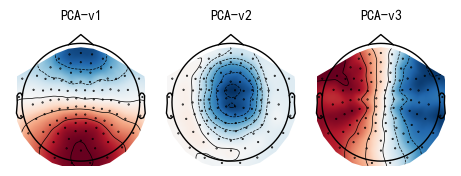

In [4]:
# 绘制 Raw 对象中已添加的 SSP（Signal Space Projection，信号空间投影）成分的地形图（Topomap）

# SSP 投影是一种常用的降维/去噪手段，通过构建正交投影矩阵来抑制特定干扰子空间（如工频噪声、心跳、眼动等），
# 该函数可以直观展示该投影成分在空间上的权重分布，帮助判断投影是否合理（例如 EOG 投影应主要集中在前额区域）
mne.viz.plot_projs_topomap(
    raw.info['projs'][:3],
    raw.info,
    sensors=True,
    # 关键：头圆半径（单位：米），否则图像会超出头圆
    sphere=0.16
)
# PCA-v1/v2/v3 是自动计算好的三个空域去噪向量（SSP 投影）
# PCA-v1	纵向分布（前后走向的红蓝区）	噪声磁场沿前后轴（y 轴）穿过的模式
# PCA-v2	环状分布（像地理里的等高线）	磁场沿垂直轴（z 轴，头顶方向）或径向穿过的模式
# PCA-v3	横向分布（左右对称的红蓝区）	噪声磁场沿左右轴（x 轴）穿过头盔的模式
plt.show()

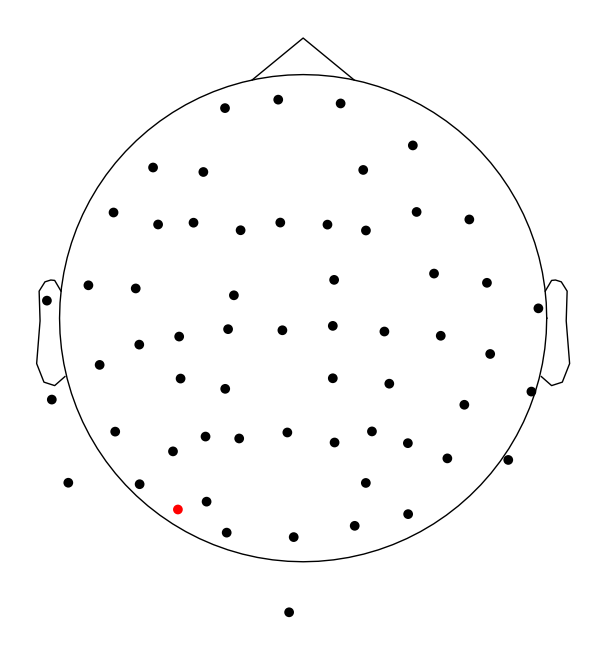

In [5]:
# 绘制电极位置
# 绘制当前 Raw 对象中所有通道（EEG 电极或 MEG 传感器）的空间位置分布图，
# 默认以三维头皮/头盔视角展示各通道的物理坐标，用于检查电极排布是否正确、是否有通道位置缺失或异常，
# 也可切换为二维平面拓扑视图（topomap 模式）
raw.plot_sensors(ch_type='eeg')
plt.show()

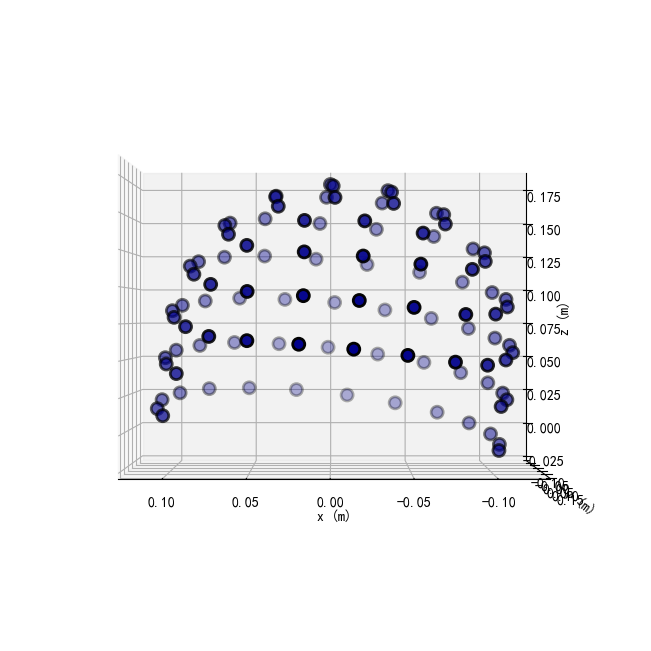

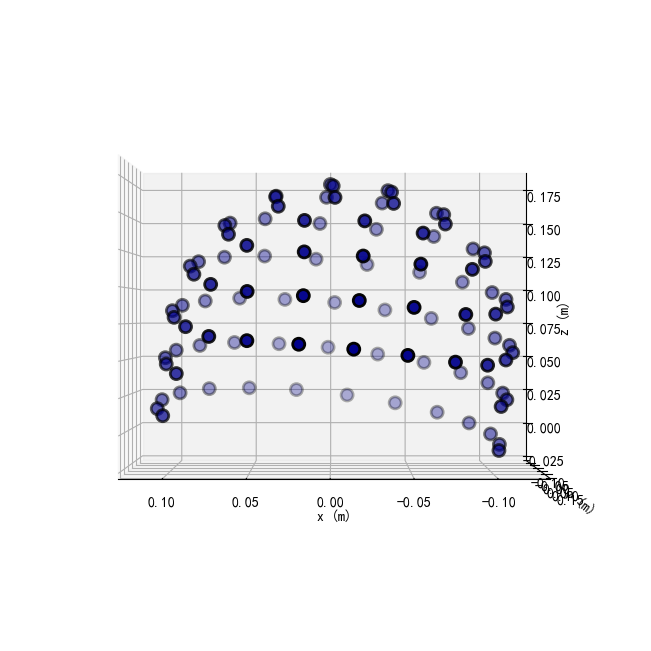

In [9]:
# 102 个磁强计传感器在头盔曲面上的三维点云
raw.plot_sensors(kind='3d', ch_type='mag')